In [43]:
# 사진이나 이미지 동영상 등은 대체적으로 용량이 커서 보관하기 힘들기 때문에
# 주성분만 분석해서 가지고 있으면 디스크용량 등에 이로움 이 있다.(차원축소 알고리즘)
#   데이터가 가진 속성을 특성이라고 함 (사진에 특성 : R:빨 G:녹 B:파 K:검 A:필터)
#   -> 과일사진의 경우 10,000개의 픽셀이 있기 때문에 10,000개의 특성이 있다.
#   -> 차원(dimension : 디멘션)

In [44]:
# 특성이 많으면 선형 모델의 성능이 높아지고 훈련 데이터에 쉽게 과대적합된다.

# 차원축소 : 데이터를 가장 잘 나타내는 일부 특성을 선택하여 데이터
#   크기를 줄이고 지도학습 모델의 성능을 향상시키기 위함

# 주성분 분석(PCA (Principal Component Analysis))
#   : 줄어준 차원에서 다시 원본 차원으로 손실을 최대한 줄이면서 복원할 수 도 있어야 함
# https://ddongwon.tistory.com/114

# 주성분 분석은 데이터에 있는 분산이 큰 방향을 찾는것으로 이해(분산 : 데이터가 널리 퍼져있는 정도)
#   -> 데이터를 잘 표현하는 벡터?

# !wget https://bit.ly/fruits_300_data -O fruits_300.npy

In [45]:
import numpy as np

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

print(fruits.shape)
print(fruits_2d.shape)

(300, 100, 100)
(300, 10000)


In [46]:
import numpy as np

fruits = np.load('fruits_300.npy')  # 300장에 100가로픽셀 * 100세로픽셀 데이터를 fruits 변수에 넣음
fruits_2d = fruits.reshape(-1, 100*100) # 300장에 10000짜리 2차원으로 변환

from sklearn.decomposition import PCA   # 주성분 분석 알고리즘사용
# 사이킷런의 decomposition 모듈 아래 PCA 클래스로 활용
pca = PCA(n_components=50) # PCA 클래스를 만들 때 주성분의 개수를 지정함 300개가 50로 압축됨
pca.fit(fruits_2d) # 비지도 학습임으로 타킷 제외 학습

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [47]:
print(pca.components_.shape) # components_ 주성분이 들어있는 속성 50개로 압축됨
# 50개의 속성에 10000개의(100x100해상도) 특성 개수

(50, 10000)


In [48]:
print(fruits_2d.shape)  # 원본 축소전 데이터

(300, 10000)


In [49]:
import matplotlib.pyplot as plt

# 이미지 출력용 메서드 가로 10개의 이미지 배열을 만들고 10개가 넘어가면 다음줄에 10개~
def draw_fruits(arr, ratio=1):  # 배열의 값을 이용해서 이미지로 출력해주는 메서드
    n = len(arr)    # n은 샘플 개수입니다
    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))
    # 행이 1개 이면 열 개수는 샘플 개수입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:    # n 개까지만 그립니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()

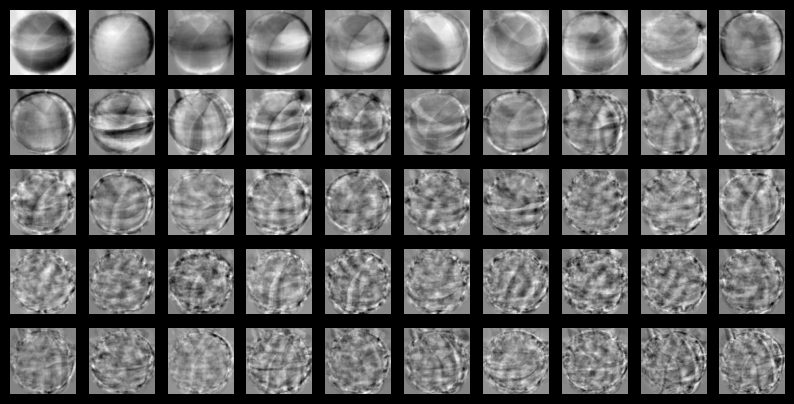

In [50]:
draw_fruits(pca.components_.reshape(-1, 100, 100)) # 10 * 5 = 50
# 주성분은 원본데이터를 투영하여 특성의 개수를 만들어 냄
# 이 주성분은 원본 데이터에서 가장 분산이 큰 방향을 순서대로 나타낸 것
# 데이터셋에 있는 어떤 특징을 잡아낸 것 처럼 생각해도 됨

In [51]:
# 주성분 분석을 이용해서 300개의 사진을 50개로 줄여 봤다.
# 이번에는 원본 데이터의 특성의 개수를 10,000개에서 50개로 줄여보자.
#   -> 원본의 분해

# transform()메서드를 사용해서 원본데이터의 차원(특성)을 줄여본다.
fruits_pca = pca.transform(fruits_2d)
print(fruits_2d.shape)  # 원본데이터 (300, 10000)
print(fruits_pca.shape) # 차원축소된 데이터 (300, 50) -> 저장용량 축소됨

(300, 10000)
(300, 50)


In [52]:
# 10000개의 특성을 50개로 줄였으니 어느정도의 손실이 발생할 수 있다.
# 하지만 최대한 분산이 큰방향으로 데이터를 투영했기 때문에
# 원본데이터를 상당부분 재구성이 가능하다.
# 원본 데이터의 재구성 -> inverse_transform()
fruits_inverse = pca.inverse_transform(fruits_pca) # 원본처럼 재구성
print(fruits_inverse.shape) # 50개의 특성을 다시 10000개로 복원

(300, 10000)


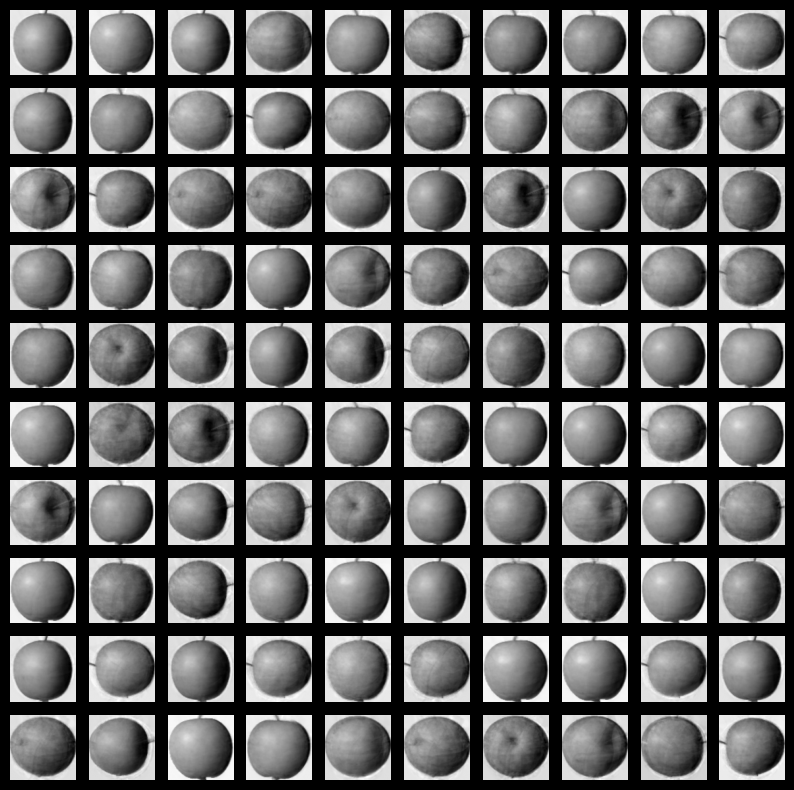

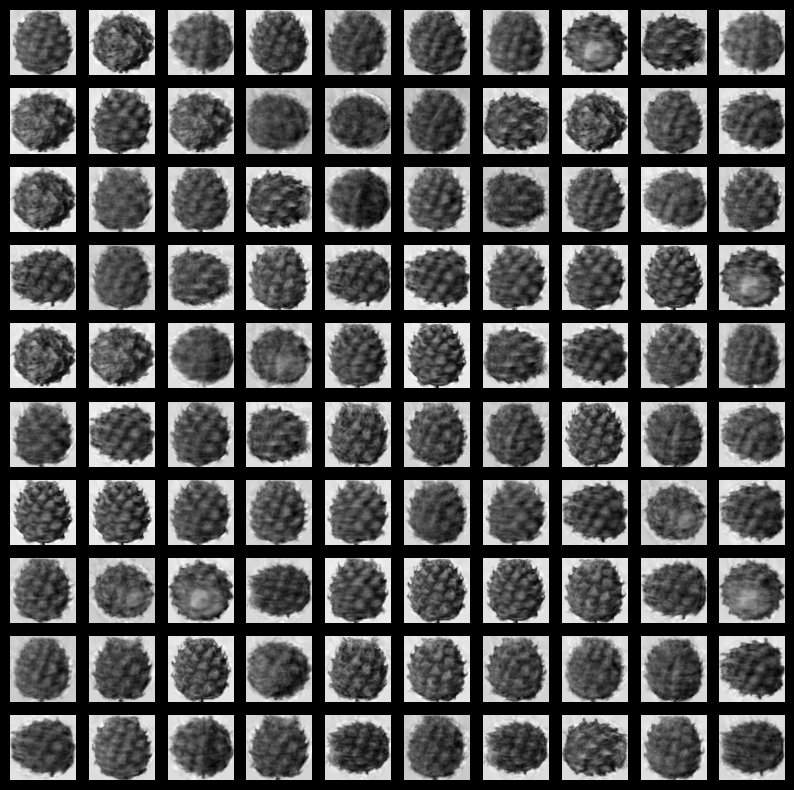

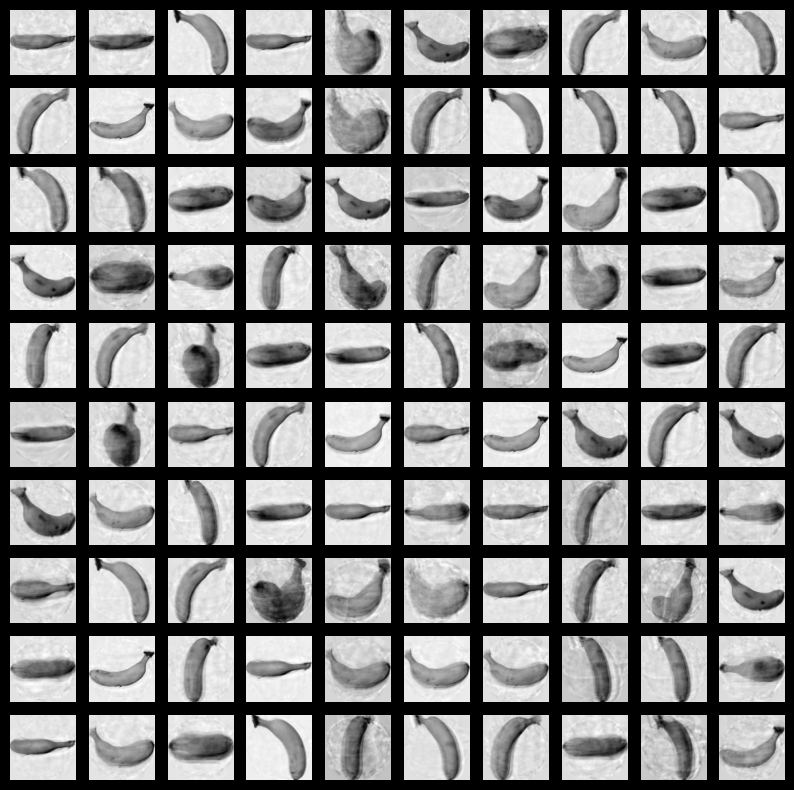

In [53]:
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100) # 모든객체 300개 100x100 픽셀
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print("\n")

In [54]:
# 거의 모든 파일이 잘 복원된듯 보인다. 특징을 잘 찾아낸 것 같고
# 일부 흐리고 번진 부분도 있지만 중요한 특성은 아님
# 불과 50개의 특성을 10,000로 늘린 것을 감안하면 성공적인듯 하다.
# 만약 주성분을 최대로 사용했다면 완벽하게 원본 데이터를 재구성할 수 있을 것이다.
# 50개의 특성은 얼마나 분산을 보존하고 있을까를 알아보자.

# 설명된 분산(explained variance) : 주성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값
# PCA 클래스의 explained_variance_ratio 에 주성분의 설명된 분산 비율이 기록되어 있음
# 첫번째 주성분의 설명된 분산이 가장큼
# 이 분산 비율을 모두 더하면 50개의 주성분으로 표현하고 있는 총 분산 비율
print(np.sum(pca.explained_variance_ratio_))
# 92%가 넘는 분산을 유지하고 있음 (이미지 품질)

0.9215678720617959


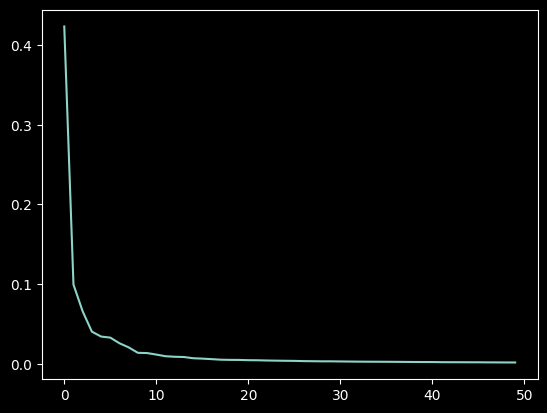

In [55]:
# 앞에서 50개의 특성에서 원본 데이터를 복원 했을 대 원본 이미지의 품질이 높은 이유가 됨
# 설명된 분산의 비율을 그래프로 그려볼 수 있다.
# 적절한 주성분의 개수를 찾는데 도움이 된다.
plt.plot(pca.explained_variance_ratio_)
# 그래프의 처음 10개가 주성분의 대부분을 표현하고 있음
# 현재 10000개의 픽셀의 성분을 50개로 줄였지만 더 줄여서 15개까지도 생각해볼 수 있겠다.

In [57]:
# 위에 만든 주성분으로 지도학습 모델에 적용 해보자.
# 전에 사용했던 로지스틱 회귀 모델을 사용

from sklearn.linear_model import LogisticRegression
# 사이킷런의 로지스틱클래스

lr = LogisticRegression(random_state=42)

# 지도학습 모델을 사용하기 위해 타깃을 생성한다.
# 사과0, 파인애플1, 바나나2
target = np.array([0] * 100 + [1] * 100 + [2] * 100) # 정답 파일 생성
# 파이썬 리스트에 정수를 곱하면 리스트 안의 원소를 정수만큼 반복함
# 100개의 0, 100개의 1, 100개의 2로 이루어진 타깃 데이터를 만듬

In [58]:
from sklearn.model_selection import cross_validate # cross_validate 크로스 검증

scores = cross_validate(lr, fruits_2d, target) # fruits_2d 원본데이터를 사용해 봄 10000픽셀
print(np.mean(scores['test_score'])) # 99%의 과대적합됨
# 특성이 10000개나 되기 때문에 300개의 샘플에서는 과대적합 모델이 됨
print(np.mean(scores['fit_time'])) # 0.82초 정도 걸림

0.9966666666666667
0.2112475872039795


In [59]:
scores = cross_validate(lr, fruits_pca, target) # fruits_pca PCA로 축소한 자료사용 50픽셀
print(np.mean(scores['test_score'])) # 99%의 과대적합 -> 위와 동일
print(np.mean(scores['fit_time']))   # 0.01초로 빠르게 처리됨
# 결론 속도가 빠르고 용량도 적다.
# PCA로 훈련데이터의 차원을 축소하면 저장공간과 시간을 절약할 수 있다.

0.9966666666666667
0.00859375


In [60]:
# 앞에서는 PCA클래스를 사용할때 n_components 매개변수에 주성분 개수를 50개로 진행 해봤다.
# 이 대신 비율로 줄 수도 있다. 50%에 달하는 주성분을 찾도록 분석을 해본다.

pca = PCA(n_components=0.5) # 주성분 개수대신 0~1 사이에 실수로 입력
pca.fit(fruits_2d)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",0.5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

In [61]:
print(pca.n_components_)    # 10000개의 특성을 2개로 압축해 버렸네요!!!
# 2개의 주성분으로 2개의 특성만으로 원본데이터의 분산 50%를 표현할 수 있다.

2


In [62]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape) # 300개의 요소에 2개의 주성분

(300, 2)


In [63]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score'])) # 99% 과대적합
print(np.mean(scores['fit_time']))  # 0.03초 훈련시간이 약간 증가
##################### 로지스틱회귀 + PCA 끝 =========================

0.9933333333333334
0.010908794403076173


C:\Users\thinkodia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\thinkodia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https

In [65]:
from sklearn.cluster import KMeans
# 차원 축소된 데이터를 사용하여 K-평균 알고리즘으로 클러스터를 찾아봄
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)  # 훈련데이터를 PCA로 주성분 분석한 자료를 활용 (300, 2)
print(fruits_pca.shape)

(300, 2)


In [66]:
print(np.unique(km.labels_, return_counts=True))
# 전에 있던 값  (array([0, 1, 2], dtype=int32), array([112,  98,  90]))
# PCA로 만든 값 (array([0, 1, 2], dtype=int32), array([110,  99,  91]))

(array([0, 1, 2]), array([110,  99,  91], dtype=int64))


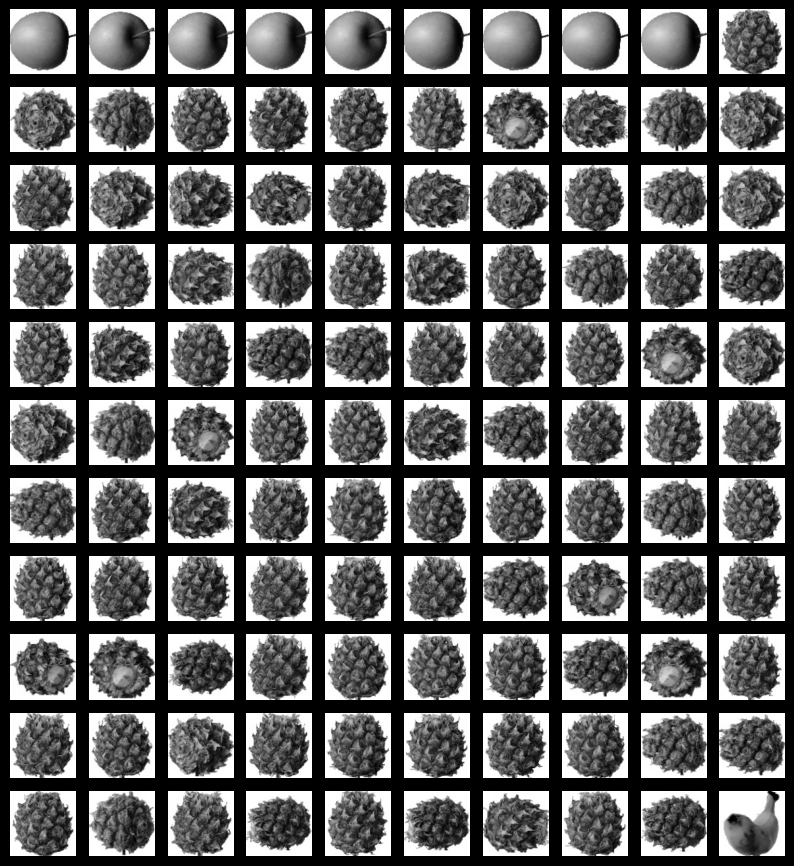

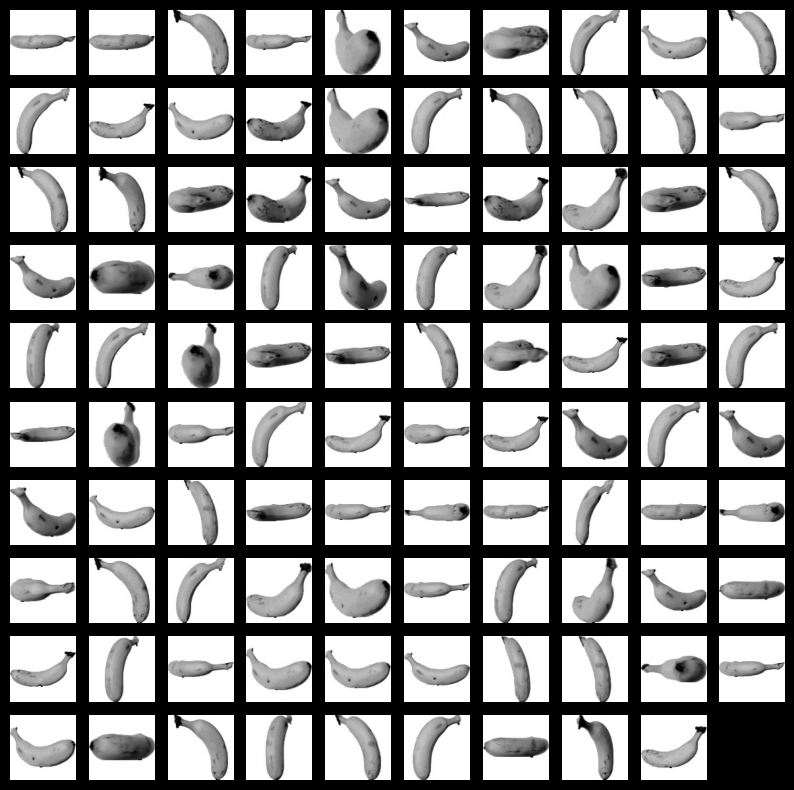

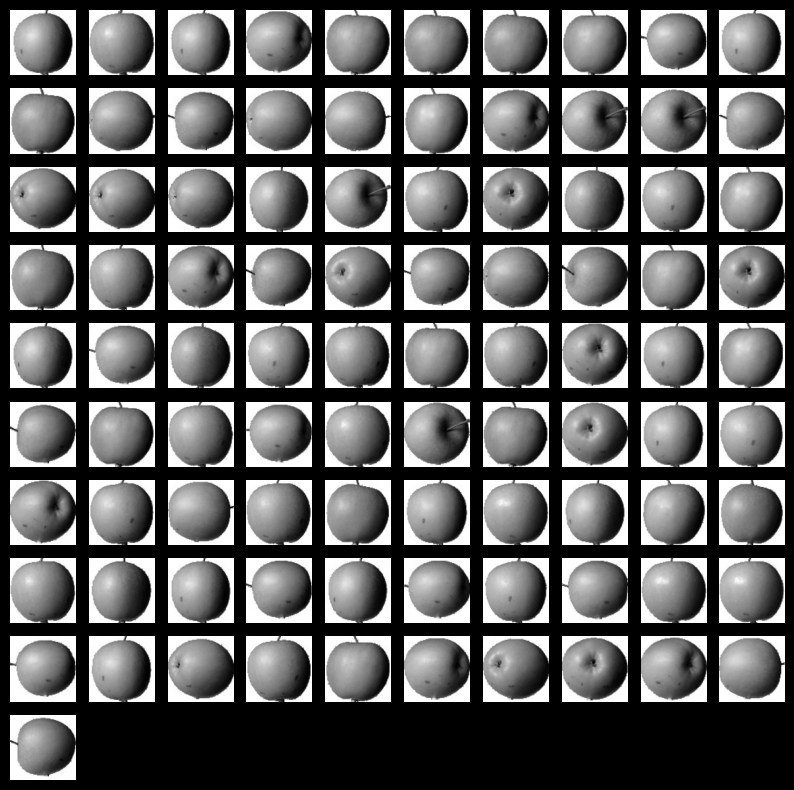

In [67]:
for label in range(0, 3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")
# KMeans가 찾은 레이블을 사용해 과일 이미지를 출력

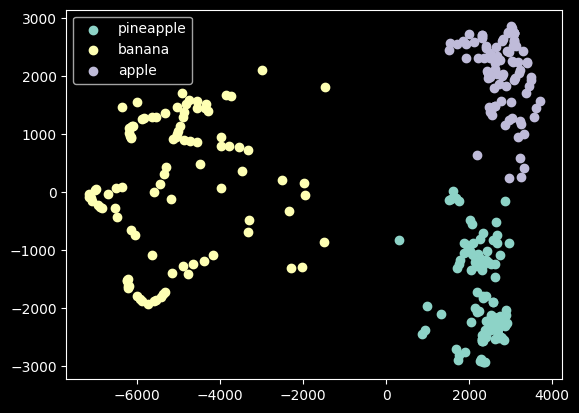

In [23]:
# 훈련 데이터의 차원을 줄이면 또 하나 얻을 수 있는 장점은 시각화가 가능하다.
# 3개 이하로 차원을 줄이면 화면에 출력하기 비교적 쉽다.
# fruits_pca 데이터가 2개의 특성으로 있기 때문에 2차원으로 표현할 수 있다.
for label in range(0, 3):
    data = fruits_pca[km.labels_ == label]
                    # km.labels_ 를 사용해 클러스터별로 나누어 산점도를 그림
    plt.scatter(data[:,0], data[:,1])
plt.legend(['pineapple', 'banana', 'apple']) # 범례표시
plt.show()